# Biaxial M-M-N Interaction Surface Tutorial

This notebook demonstrates the complete functionality of the biaxial M-M-N interaction surface implementation using fibre-based strain compatibility analysis per Eurocode 2.

## Table of Contents

1. [Setup and Imports](#setup)
2. [Create Materials](#materials)
3. [Create RC Column with Reinforcement](#section)
4. [Create Biaxial M-M-N Interaction Surface](#create-surface)
5. [Generate Complete Surface](#generate-surface)
6. [Visualize the 3D Surface](#visualize)
7. [Understanding Neutral Axis Angles](#neutral-axis)
8. [Section Symmetry Analysis](#symmetry)
9. [Asymmetric Sections](#asymmetric)
10. [ULS Persistent/Transient vs. Accidental Limit States](#uls-comparison)
11. [Capacity Checking with Vector Method](#capacity-check)


## 1. Setup and Imports <a id='setup'></a>

First, let's import all necessary modules and set up plotting.

In [ ]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt

# Materials library imports
from section_design_checks.reinforced_concrete.materials import ConcreteMaterial, Rebar
from section_design_checks.reinforced_concrete.geometry import (
    create_rectangular_section,
    create_linear_rebar_layer,
)
from section_design_checks.reinforced_concrete.analysis.biaxial_interaction import (
    create_biaxial_interaction_surface,
)

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.size'] = 10

print("✓ Imports successful")

✓ Imports successful


## 2. Create Materials <a id='materials'></a>

Define concrete and reinforcing steel materials according to Eurocode 2.

In [2]:
# Create C30/37 concrete
concrete = ConcreteMaterial(
    grade="C30/37",
    gamma_c=1.5,      # Partial safety factor
    alpha_cc=0.85,    # Long-term strength reduction factor
)

print("Concrete Material Properties:")
print(f"  Grade:     {concrete.grade}")
print(f"  f_ck:      {concrete.f_ck:.1f} MPa  (characteristic strength)")
print(f"  f_cd:      {concrete.f_cd:.1f} MPa  (design strength)")
print(f"  E_cm:      {concrete.E_cm:.0f} MPa (elastic modulus)")
print(f"  ε_cu2:     {concrete.epsilon_cu2:.5f}   (ultimate strain)")
print()

# Create B500B reinforcing steel
rebar_20 = Rebar(
    grade="B500B",
    diameter=20,      # mm
)

print("Reinforcement Properties:")
print(f"  Grade:     {rebar_20.grade}")
print(f"  Diameter:  ϕ{rebar_20.diameter} mm")
print(f"  Area:      {rebar_20.area:.1f} mm²")
print(f"  f_yk:      {rebar_20.f_yk:.1f} MPa")
print(f"  f_yd:      {rebar_20.f_yd:.1f} MPa")

Concrete Material Properties:
  Grade:     C30/37
  f_ck:      30.0 MPa  (characteristic strength)
  f_cd:      17.0 MPa  (design strength)
  E_cm:      32837 MPa (elastic modulus)
  ε_cu2:     0.00350   (ultimate strain)

Reinforcement Properties:
  Grade:     B500B
  Diameter:  ϕ20.0 mm
  Area:      314.2 mm²
  f_yk:      500.0 MPa
  f_yd:      434.8 MPa


## 3. Create RC Column with Reinforcement <a id='section'></a>

Create a 400×400 mm square column section with corner reinforcement.

**Axis Convention (3D FEA standard):**
- **x-axis**: Longitudinal axis (along member length)
- **y-axis**: Horizontal axis in cross-section (minor axis, width)
- **z-axis**: Vertical axis in cross-section (major axis, height)
- **My**: Moment about y-axis (major axis bending, from z-direction forces)
- **Mz**: Moment about z-axis (minor axis bending, from y-direction forces)

In [3]:
# Create square column section
column = create_rectangular_section(
    width=400,
    height=400,
    section_name="Square Column 400×400",
)

print(f"Section: {column.section_name}")
print(f"  Dimensions: 400×400 mm")
print(f"  Gross area: {column.get_area():.0f} mm²")
print()

# Add corner reinforcement: 4×ϕ20 bars
cover = 50  # mm
corners = [
    (cover, cover),                    # Bottom-left
    (400 - cover, cover),              # Bottom-right
    (400 - cover, 400 - cover),        # Top-right
    (cover, 400 - cover),              # Top-left
]

for i, (x, y) in enumerate(corners):
    corner_bar = create_linear_rebar_layer(
        rebar=rebar_20,
        n_bars=1,
        start_point=(x, y),
        end_point=(x, y),
        layer_name=f"corner_{i+1}",
    )
    column.add_rebar_group(corner_bar)

print(f"Reinforcement: 4×ϕ20 corner bars")
print(f"  Total steel area: {column.total_steel_area:.0f} mm²")
print(f"  Reinforcement ratio: {column.reinforcement_ratio:.4f} ({column.reinforcement_ratio*100:.2f}%)")
print(f"  Cover: {cover} mm")

Section: Square Column 400×400
  Dimensions: 400×400 mm
  Gross area: 160000 mm²

Reinforcement: 4×ϕ20 corner bars
  Total steel area: 1257 mm²
  Reinforcement ratio: 0.0079 (0.79%)
  Cover: 50 mm


### Visualize Column Cross-Section

In [4]:
column.plot(concrete=concrete, show=False)

## 4. Create Biaxial M-M-N Interaction Surface <a id='create-surface'></a>

Initialize the biaxial interaction surface generator.

### Key Parameters:
- **concrete_model_type**: EC2 stress-strain model
  - `"parabola-rectangle"`: EC2 Figure 3.3 (most accurate)
  - `"bilinear"`: EC2 Figure 3.4 (simplified)

- **steel_branch_type**: Post-yield behavior
  - `"inclined"`: With strain hardening (more accurate)
  - `"horizontal"`: Perfectly plastic (conservative)

- **Fibre mesh resolution**: Balance accuracy vs. speed
  - Default: 30×30 fibres

In [5]:
# Create biaxial M-M-N interaction surface
surface = create_biaxial_interaction_surface(
    section=column,
    concrete=concrete,
    concrete_model_type="parabola-rectangle",  # EC2 Fig 3.3
    steel_model_type="inclined",              # With strain hardening
    n_fibres_width=30,
    n_fibres_height=30,
)

print(surface)
print()
print(f"Fibre mesh: {surface.mesh.total_fibres} total fibres")
print(f"  Concrete fibres: {surface.mesh.n_concrete_fibres}")
print(f"  Steel fibres: {surface.mesh.n_steel_fibres}")

BiaxialMNInteractionSurface(section=Square Column 400×400, concrete=C30/37)

Fibre mesh: 904 total fibres
  Concrete fibres: 900
  Steel fibres: 4


## 5. Generate Complete Surface <a id='generate-surface'></a>

The `generate_surface_pivot()` method creates the complete M-M-N interaction surface using **constant-N contours**:

1. Define target axial force (N) levels from pure tension to pure compression
2. For each N level, sweep through neutral axis angles (0° to 360°)
3. At each angle, solve for the neutral axis depth that produces the target N
4. This creates closed elliptical contours at each N level → **rugby ball shape**

In [6]:
# Generate surface with high resolution for smooth rugby ball shape
print("Generating biaxial M-M-N interaction surface...")
print("This may take a moment (solving ~3000 nonlinear equations)...")
print()

points = surface.generate_surface_pivot(
    n_angles=60,         # Points per contour (60 angles around each ellipse)
    n_axial_levels=50,   # Number of N levels (50 horizontal slices)
)

print(f"✓ Generated {len(points)} points on M-M-N surface")
print()

# Extract coordinate arrays
N_values = [p.N for p in points]
My_values = [p.My for p in points]
Mz_values = [p.Mz for p in points]

# Summary statistics
print("Surface Statistics:")
print(f"  N range:  {min(N_values):.1f} to {max(N_values):.1f} kN")
print(f"  My range: {min(My_values):.1f} to {max(My_values):.1f} kN·m")
print(f"  Mz range: {min(Mz_values):.1f} to {max(Mz_values):.1f} kN·m")

Generating biaxial M-M-N interaction surface...
This may take a moment (solving ~3000 nonlinear equations)...

✓ Generated 3000 points on M-M-N surface

Surface Statistics:
  N range:  -578.3 to 3124.8 kN
  My range: -211.1 to 211.1 kN·m
  Mz range: -211.1 to 211.1 kN·m


## 6. Visualize the 3D Surface <a id='visualize'></a>

Plot the M-M-N interaction surface in 3D space.

In [7]:
# Visualize using the new plot() method
fig = surface.plot(
    show=True,
    title="Biaxial M-M-N Interaction Surface\nSquare Column 400×400 mm, 4×ϕ20, C30/37",
    n_angles=36,
    n_axial_levels=20
)

# The interactive Plotly plot shows:
# - Translucent surface with Delaunay triangulation
# - Latitude rings (constant N contours) with faint black lines
# - Longitude lines (constant angle rays) with faint black lines
# - Hover to see coordinates at each point
# - Rotate, pan, and zoom in 3D space

### Multiple Views of the Surface

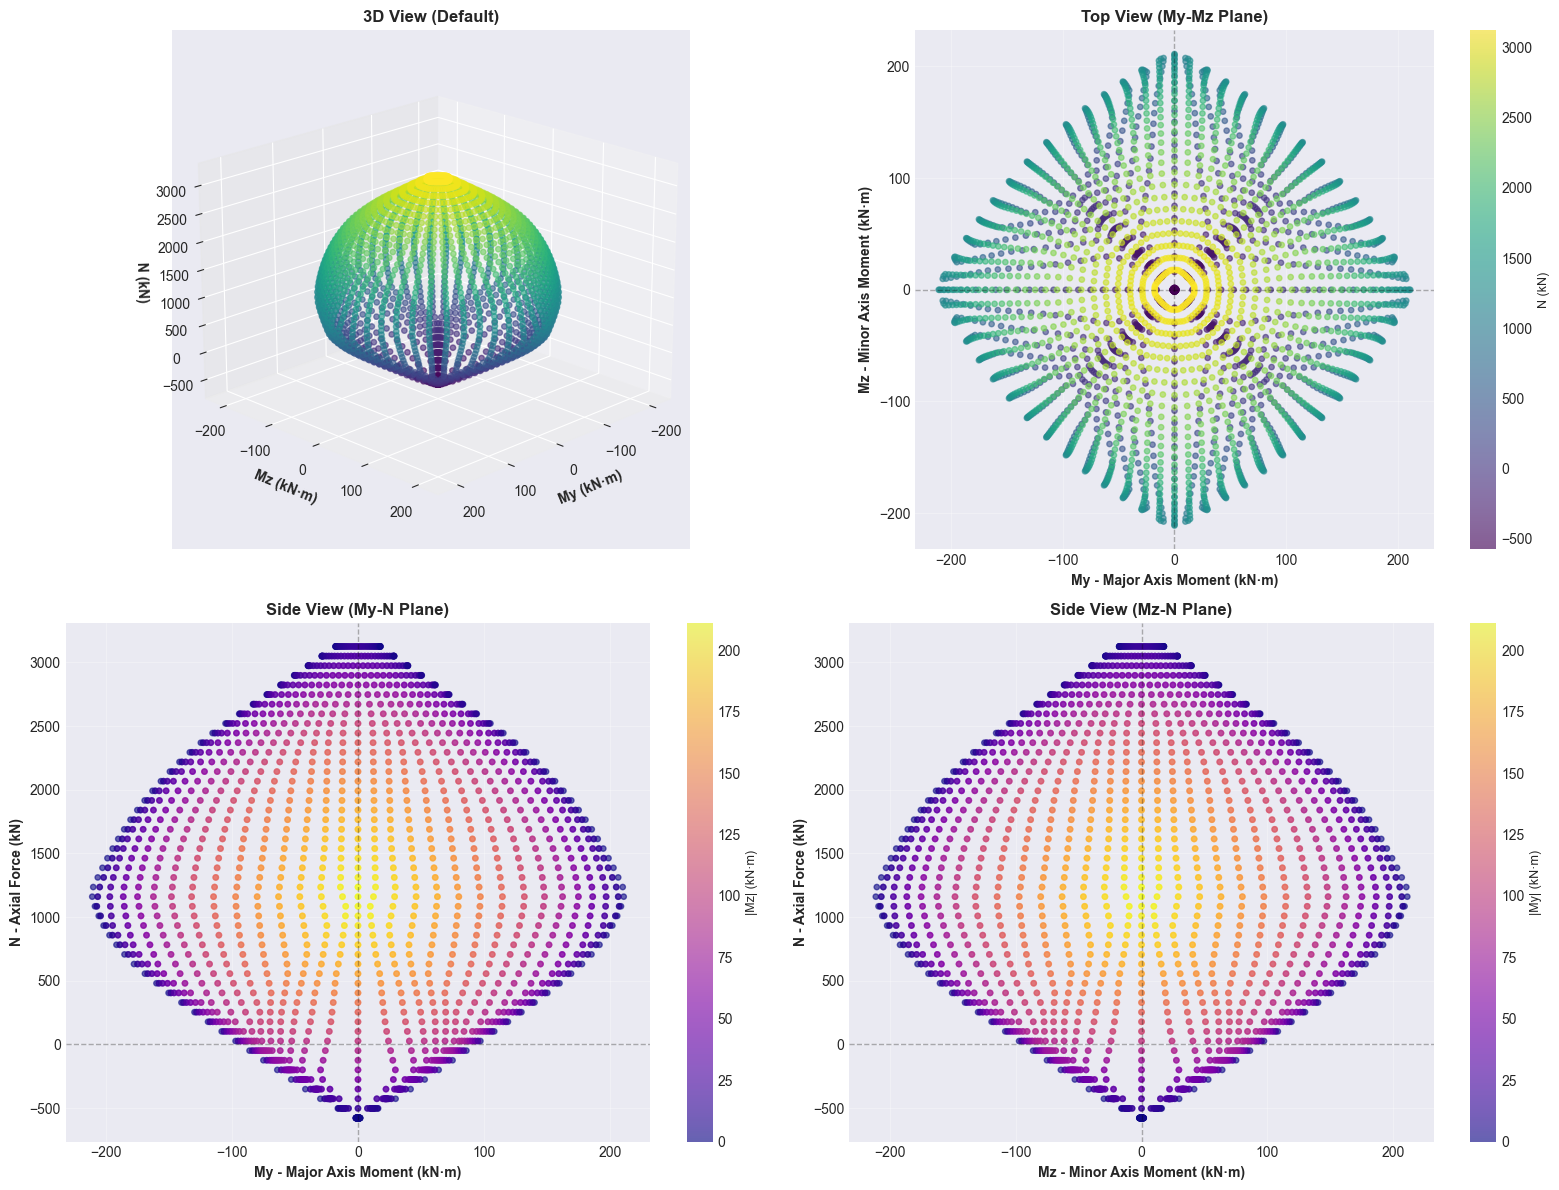

In [8]:
# Create figure with multiple subplots showing different views
fig = plt.figure(figsize=(16, 12))

# View 1: Default 3D view
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter(My_values, Mz_values, N_values, c=N_values, cmap='viridis', s=15, alpha=0.6)
ax1.set_xlabel('My (kN·m)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Mz (kN·m)', fontsize=10, fontweight='bold')
ax1.set_zlabel('N (kN)', fontsize=10, fontweight='bold')
ax1.set_title('3D View (Default)', fontsize=12, fontweight='bold')
ax1.view_init(elev=20, azim=45)
ax1.grid(True, alpha=0.3)

# View 2: Top view (looking down at My-Mz plane)
ax2 = fig.add_subplot(2, 2, 2)
scatter2 = ax2.scatter(My_values, Mz_values, c=N_values, cmap='viridis', s=15, alpha=0.6)
ax2.axhline(0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax2.axvline(0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax2.set_xlabel('My - Major Axis Moment (kN·m)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Mz - Minor Axis Moment (kN·m)', fontsize=10, fontweight='bold')
ax2.set_title('Top View (My-Mz Plane)', fontsize=12, fontweight='bold')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('N (kN)', fontsize=9)

# View 3: Side view (My-N plane)
ax3 = fig.add_subplot(2, 2, 3)
scatter3 = ax3.scatter(My_values, N_values, c=np.abs(Mz_values), cmap='plasma', s=15, alpha=0.6)
ax3.axhline(0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax3.axvline(0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax3.set_xlabel('My - Major Axis Moment (kN·m)', fontsize=10, fontweight='bold')
ax3.set_ylabel('N - Axial Force (kN)', fontsize=10, fontweight='bold')
ax3.set_title('Side View (My-N Plane)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
cbar3 = plt.colorbar(scatter3, ax=ax3)
cbar3.set_label('|Mz| (kN·m)', fontsize=9)

# View 4: Side view (Mz-N plane)
ax4 = fig.add_subplot(2, 2, 4)
scatter4 = ax4.scatter(Mz_values, N_values, c=np.abs(My_values), cmap='plasma', s=15, alpha=0.6)
ax4.axhline(0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax4.axvline(0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax4.set_xlabel('Mz - Minor Axis Moment (kN·m)', fontsize=10, fontweight='bold')
ax4.set_ylabel('N - Axial Force (kN)', fontsize=10, fontweight='bold')
ax4.set_title('Side View (Mz-N Plane)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
cbar4 = plt.colorbar(scatter4, ax=ax4)
cbar4.set_label('|My| (kN·m)', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Section Symmetry Analysis <a id='symmetry'></a>

For a square column with symmetric reinforcement, the M-M-N surface should exhibit 4-fold rotational symmetry.

In [9]:
# Test symmetry at key angles
test_depth = 200.0
symmetry_angles = [0, 90, 180, 270]

print("Symmetry Check (NA depth = 200 mm):\n")
print(f" {'Angle':>7} | {'N (kN)':>10} | {'My (kN·m)':>12} | {'Mz (kN·m)':>12} | {'|M| (kN·m)':>12}")
print("-" * 70)

symmetry_points = []
for angle in symmetry_angles:
    p = surface.calculate_point_pivot(test_depth, angle)
    M_total = np.sqrt(p.My**2 + p.Mz**2)
    symmetry_points.append(p)
    print(f"{angle:>7}° | {p.N:>10.1f} | {p.My:>12.1f} | {p.Mz:>12.1f} | {M_total:>12.1f}")

print("\nFor perfect symmetry:")
print("  - N should be identical at all angles")
print("  - |My| at 0° should equal |Mz| at 90°")
print("  - |My| at 180° should equal |Mz| at 270°")
print("  - Total moment magnitude |M| should be constant")

Symmetry Check (NA depth = 200 mm):

   Angle |     N (kN) |    My (kN·m) |    Mz (kN·m) |   |M| (kN·m)
----------------------------------------------------------------------
      0° |     1134.0 |        210.6 |         -0.0 |        210.6
     90° |     1134.0 |         -0.0 |        210.6 |        210.6
    180° |     1134.0 |       -210.6 |         -0.0 |        210.6
    270° |     1134.0 |         -0.0 |       -210.6 |        210.6

For perfect symmetry:
  - N should be identical at all angles
  - |My| at 0° should equal |Mz| at 90°
  - |My| at 180° should equal |Mz| at 270°
  - Total moment magnitude |M| should be constant


## 8. Asymmetric Sections <a id='asymmetric'></a>

Create a rectangular column to demonstrate how asymmetry affects the M-M-N surface.

In [10]:
# Create rectangular column: 300mm × 500mm
rect_column = create_rectangular_section(
    width=300,
    height=500,
    section_name="Rectangular Column 300×500",
)

# Add corner reinforcement
cover = 50
rect_corners = [
    (cover, cover),
    (300 - cover, cover),
    (300 - cover, 500 - cover),
    (cover, 500 - cover),
]

for i, (x, y) in enumerate(rect_corners):
    corner_bar = create_linear_rebar_layer(
        rebar=rebar_20,
        n_bars=1,
        start_point=(x, y),
        end_point=(x, y),
        layer_name=f"corner_{i+1}",
    )
    rect_column.add_rebar_group(corner_bar)

print(f"Created: {rect_column.section_name}")
print(f"  Width: 300 mm (minor axis)")
print(f" Height: 500 mm (major axis)")
print(f"  Steel: 4×ϕ20 corner bars")
print()

# Generate surface for rectangular column
print("Generating surface for rectangular column...")
rect_surface = create_biaxial_interaction_surface(
    section=rect_column,
    concrete=concrete,
)

rect_points = rect_surface.generate_surface_pivot(n_angles=36, n_axial_levels=20)

print(f"✓ Generated {len(rect_points)} points")

Created: Rectangular Column 300×500
  Width: 300 mm (minor axis)
 Height: 500 mm (major axis)
  Steel: 4×ϕ20 corner bars

Generating surface for rectangular column...
✓ Generated 720 points


### Compare Square vs. Rectangular Column Surfaces

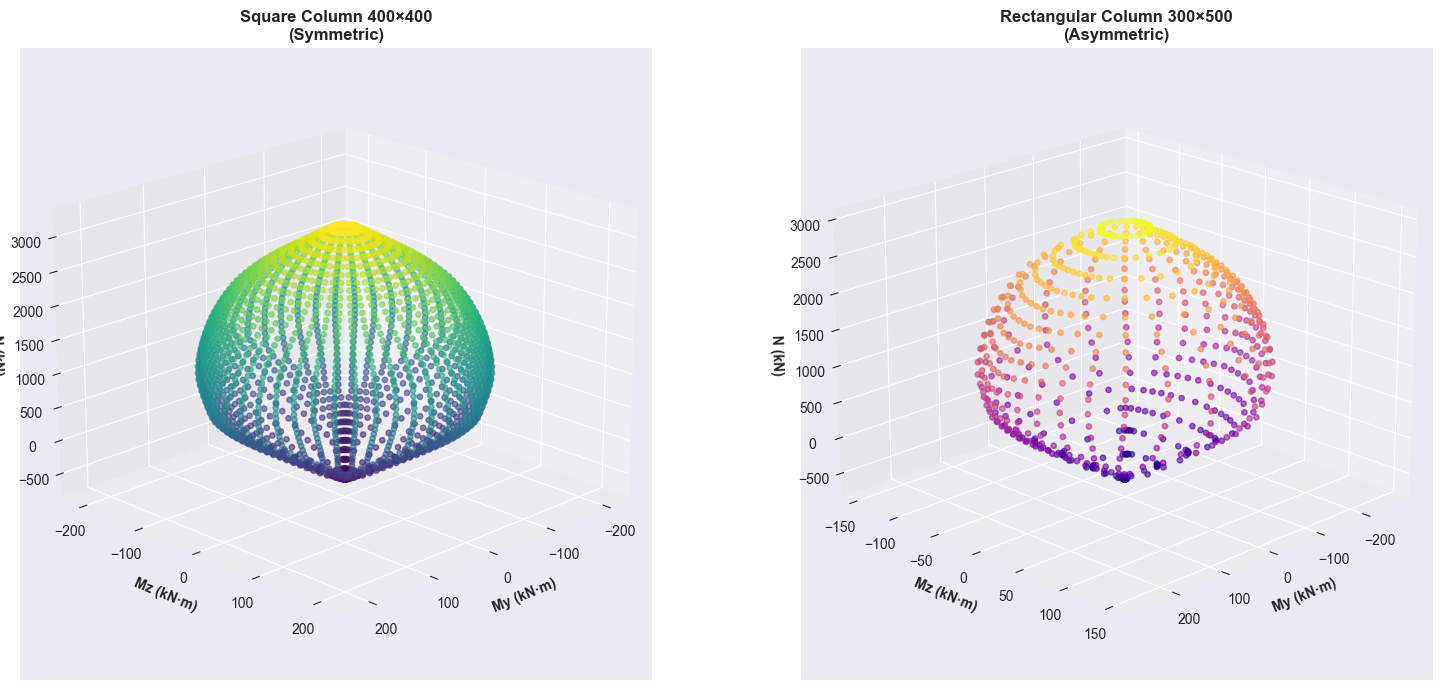


Key Differences:
  Square column: Circular/symmetric cross-section in My-Mz plane
  Rectangular column: Elliptical cross-section in My-Mz plane
                      (larger extent in My direction due to greater height)


In [11]:
# Extract rectangular column data
N_rect = [p.N for p in rect_points]
My_rect = [p.My for p in rect_points]
Mz_rect = [p.Mz for p in rect_points]

# Create comparison plot
fig = plt.figure(figsize=(16, 7))

# Left: Square column
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(My_values, Mz_values, N_values, c=N_values, cmap='viridis', s=15, alpha=0.6)
ax1.set_xlabel('My (kN·m)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Mz (kN·m)', fontsize=10, fontweight='bold')
ax1.set_zlabel('N (kN)', fontsize=10, fontweight='bold')
ax1.set_title('Square Column 400×400\n(Symmetric)', fontsize=12, fontweight='bold')
ax1.view_init(elev=20, azim=45)
ax1.grid(True, alpha=0.3)

# Right: Rectangular column
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(My_rect, Mz_rect, N_rect, c=N_rect, cmap='plasma', s=15, alpha=0.6)
ax2.set_xlabel('My (kN·m)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Mz (kN·m)', fontsize=10, fontweight='bold')
ax2.set_zlabel('N (kN)', fontsize=10, fontweight='bold')
ax2.set_title('Rectangular Column 300×500\n(Asymmetric)', fontsize=12, fontweight='bold')
ax2.view_init(elev=20, azim=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Differences:")
print("  Square column: Circular/symmetric cross-section in My-Mz plane")
print("  Rectangular column: Elliptical cross-section in My-Mz plane")
print("                      (larger extent in My direction due to greater height)")

### Top View Comparison

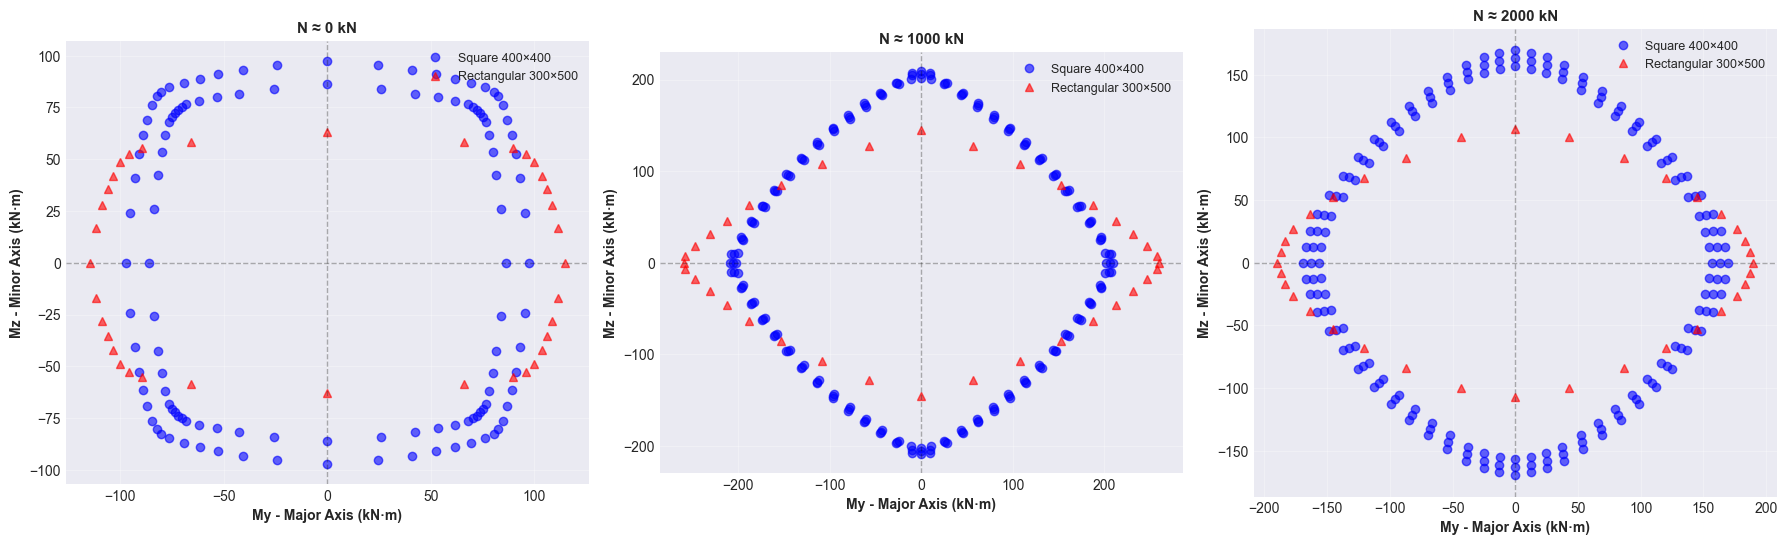

In [12]:
# Create top-view comparison at specific N levels
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Helper function to filter points by N range
def filter_by_N(points, N_target, N_tolerance=100):
    filtered = [p for p in points if abs(p.N - N_target) < N_tolerance]
    My = [p.My for p in filtered]
    Mz = [p.Mz for p in filtered]
    return My, Mz

# Three N levels
N_levels = [0, 1000, 2000]

for ax, N_level in zip(axes, N_levels):
    # Square column
    My_sq, Mz_sq = filter_by_N(points, N_level)
    ax.plot(My_sq, Mz_sq, 'bo', markersize=6, alpha=0.6, label='Square 400×400')
    
    # Rectangular column
    My_rc, Mz_rc = filter_by_N(rect_points, N_level)
    ax.plot(My_rc, Mz_rc, 'r^', markersize=6, alpha=0.6, label='Rectangular 300×500')
    
    ax.axhline(0, color='k', linestyle='--', alpha=0.3, linewidth=1)
    ax.axvline(0, color='k', linestyle='--', alpha=0.3, linewidth=1)
    ax.set_xlabel('My - Major Axis (kN·m)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Mz - Minor Axis (kN·m)', fontsize=10, fontweight='bold')
    ax.set_title(f'N ≈ {N_level} kN', fontsize=11, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

## 9. ULS Persistent/Transient vs. Accidental Limit States <a id='uls-comparison'></a>

Compare interaction surfaces for different ultimate limit state conditions per EN 1992-1-1:

**ULS Persistent/Transient Design:**
- Concrete: γc = 1.5, αcc = 0.85 (standard partial factors)
- Steel: γs = 1.15
- Used for normal design situations (dead load, live load, wind, etc.)

**ULS Accidental Design:**
- Concrete: γc = 1.2, αcc = 0.85 (reduced partial factors)
- Steel: γs = 1.0
- Used for exceptional events (seismic, impact, fire aftermath, etc.)
- Higher material strengths allowed due to lower probability of occurrence

In [13]:
# Create materials for ULS Persistent/Transient (standard design)
concrete_persistent = ConcreteMaterial(
    grade="C30/37",
    gamma_c=1.5,      # Standard partial safety factor
    alpha_cc=0.85     # Long-term strength reduction
)

# Create materials for ULS Accidental (exceptional events)
concrete_accidental = ConcreteMaterial(
    grade="C30/37",
    gamma_c=1.2,      # Reduced partial safety factor for accidental situations
    alpha_cc=0.85
)

print("Material Comparison:")
print("="*70)
print(f"{'Property':<30} | {'ULS Persistent':>15} | {'ULS Accidental':>15}")
print("-"*70)
print(f"{'Concrete γc':<30} | {concrete_persistent.gamma_c:>15.2f} | {concrete_accidental.gamma_c:>15.2f}")
print(f"{'f_cd (MPa)':<30} | {concrete_persistent.f_cd:>15.1f} | {concrete_accidental.f_cd:>15.1f}")
print(f"{'f_yd (MPa) - Steel γs=1.15':<30} | {rebar_20.f_yd:>15.1f} | {'-':>15}")
print(f"{'f_yd (MPa) - Steel γs=1.0':<30} | {'-':>15} | {rebar_20.f_yk:>15.1f}")
print()
print(f"Design strength increase for accidental:")
print(f"  Concrete: {concrete_accidental.f_cd / concrete_persistent.f_cd:.1%}")
print(f"  Steel:    {rebar_20.f_yk / rebar_20.f_yd:.1%}")
print()

# Note: For accidental design, we need to use gamma_s = 1.0 for steel
# The Rebar class uses gamma_s=1.15 by default, so f_yd for accidental would be f_yk
print("Note: Steel design strength for accidental = f_yk (no partial factor)")

Material Comparison:
Property                       |  ULS Persistent |  ULS Accidental
----------------------------------------------------------------------
Concrete γc                    |            1.50 |            1.20
f_cd (MPa)                     |            17.0 |            21.2
f_yd (MPa) - Steel γs=1.15     |           434.8 |               -
f_yd (MPa) - Steel γs=1.0      |               - |           500.0

Design strength increase for accidental:
  Concrete: 125.0%
  Steel:    115.0%

Note: Steel design strength for accidental = f_yk (no partial factor)


In [14]:
# Generate surfaces for both limit states using the same column section
print("Generating surfaces for ULS comparison...")
print()

# ULS Persistent/Transient surface (using existing 'surface' from earlier)
print("1. ULS Persistent/Transient (standard design factors)...")
persistent_points = surface.generate_surface_pivot(n_angles=36, n_axial_levels=20)
print(f"   ✓ Generated {len(persistent_points)} points")

# ULS Accidental surface (reduced partial factors)
print("2. ULS Accidental (reduced factors for exceptional events)...")
surface_accidental = create_biaxial_interaction_surface(
    section=column,  # Same section
    concrete=concrete_accidental,  # Different material properties
    concrete_model_type="parabola-rectangle",
    steel_model_type="inclined",
    n_fibres_width=30,
    n_fibres_height=30,
)
accidental_points = surface_accidental.generate_surface_pivot(n_angles=36, n_axial_levels=20)
print(f"   ✓ Generated {len(accidental_points)} points")
print()

# Extract data
N_persistent = [p.N for p in persistent_points]
My_persistent = [p.My for p in persistent_points]
Mz_persistent = [p.Mz for p in persistent_points]

N_accidental = [p.N for p in accidental_points]
My_accidental = [p.My for p in accidental_points]
Mz_accidental = [p.Mz for p in accidental_points]

print("Surface Statistics:")
print(f"{'Limit State':<20} | {'N Range (kN)':<20} | {'My Range (kN·m)':<20} | {'Mz Range (kN·m)':<20}")
print("-"*100)
print(f"{'ULS Persistent':<20} | {min(N_persistent):>8.0f} to {max(N_persistent):>8.0f} | {min(My_persistent):>8.1f} to {max(My_persistent):>8.1f} | {min(Mz_persistent):>8.1f} to {max(Mz_persistent):>8.1f}")
print(f"{'ULS Accidental':<20} | {min(N_accidental):>8.0f} to {max(N_accidental):>8.0f} | {min(My_accidental):>8.1f} to {max(My_accidental):>8.1f} | {min(Mz_accidental):>8.1f} to {max(Mz_accidental):>8.1f}")
print()
print(f"Capacity increase (Accidental / Persistent):")
print(f"  Max N:    {max(N_accidental) / max(N_persistent):.1%}")
print(f"  Max |My|: {max(abs(min(My_accidental)), abs(max(My_accidental))) / max(abs(min(My_persistent)), abs(max(My_persistent))):.1%}")
print(f"  Max |Mz|: {max(abs(min(Mz_accidental)), abs(max(Mz_accidental))) / max(abs(min(Mz_persistent)), abs(max(Mz_persistent))):.1%}")

Generating surfaces for ULS comparison...

1. ULS Persistent/Transient (standard design factors)...
   ✓ Generated 720 points
2. ULS Accidental (reduced factors for exceptional events)...
   ✓ Generated 720 points

Surface Statistics:
Limit State          | N Range (kN)         | My Range (kN·m)      | Mz Range (kN·m)     
----------------------------------------------------------------------------------------------------
ULS Persistent       |     -578 to     3039 |   -210.6 to    210.6 |   -210.6 to    210.6
ULS Accidental       |     -578 to     3675 |   -243.1 to    243.1 |   -243.1 to    243.1

Capacity increase (Accidental / Persistent):
  Max N:    120.9%
  Max |My|: 115.4%
  Max |Mz|: 115.4%


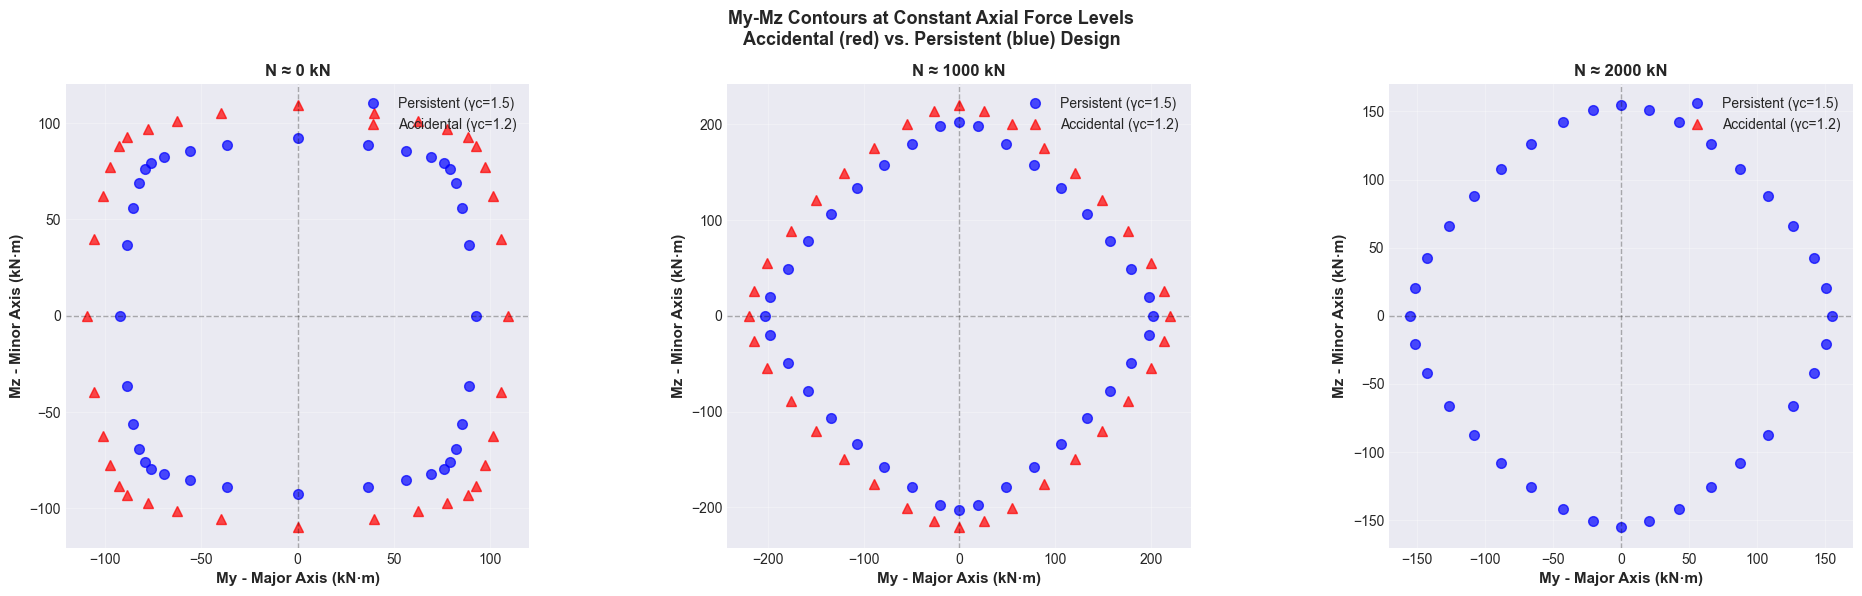


Contour Analysis:
  - At each N level, accidental contour is larger (encloses more area)
  - Capacity increase is consistent across all load combinations
  - For biaxial bending, both My and Mz capacity increase proportionally


In [15]:
# Compare surfaces at specific N levels (top view of My-Mz plane)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Helper function filter_by_N already defined in earlier cells
N_levels = [0, 1000, 2000]

for ax, N_level in zip(axes, N_levels):
    # ULS Persistent/Transient
    My_pers, Mz_pers = filter_by_N(persistent_points, N_level, N_tolerance=100)
    ax.plot(My_pers, Mz_pers, 'bo', markersize=7, alpha=0.7, 
           label=f'Persistent (γc=1.5)')
    
    # ULS Accidental
    My_acc, Mz_acc = filter_by_N(accidental_points, N_level, N_tolerance=100)
    ax.plot(My_acc, Mz_acc, 'r^', markersize=7, alpha=0.7, 
           label=f'Accidental (γc=1.2)')
    
    ax.axhline(0, color='k', linestyle='--', alpha=0.3, linewidth=1)
    ax.axvline(0, color='k', linestyle='--', alpha=0.3, linewidth=1)
    ax.set_xlabel('My - Major Axis (kN·m)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mz - Minor Axis (kN·m)', fontsize=11, fontweight='bold')
    ax.set_title(f'N ≈ {N_level} kN', fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)

plt.suptitle('My-Mz Contours at Constant Axial Force Levels\nAccidental (red) vs. Persistent (blue) Design',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nContour Analysis:")
print("  - At each N level, accidental contour is larger (encloses more area)")
print("  - Capacity increase is consistent across all load combinations")
print("  - For biaxial bending, both My and Mz capacity increase proportionally")

## 10. Capacity Checking with Vector Method <a id='capacity-check'></a>

The `get_utilization_vector()` method checks capacity using 3D vector projection for biaxial bending.

This is the geometrically correct method that projects a vector from the origin through the applied load point (N_Ed, My_Ed, Mz_Ed) and finds the intersection with the interaction surface boundary.

In [16]:
# Example 1: Single load case (surface generated automatically)
print("Example 1: Single Load Case")
print("="*70)
print()

# Applied loads on square column
N_Ed = 1500  # kN (compression)
My_Ed = 100  # kN·m (major axis)
Mz_Ed = 50   # kN·m (minor axis)

is_safe, utilization = surface.get_utilization_vector(
    N_Ed=N_Ed,
    My_Ed=My_Ed,
    Mz_Ed=Mz_Ed,
    n_angles=72,
    n_axial_levels=30
)

print(f"Applied loads:")
print(f"  N_Ed  = {N_Ed:.1f} kN")
print(f"  My_Ed = {My_Ed:.1f} kN·m")
print(f"  Mz_Ed = {Mz_Ed:.1f} kN·m")
print()
print(f"Result:")
print(f"  Safe: {is_safe}")
print(f"  Utilization: {utilization:.1%}")
if is_safe:
    print(f"  Status: ✓ PASS - Section capacity adequate")
else:
    print(f"  Status: ✗ FAIL - Section capacity exceeded")
print()
print()

# Example 2: Multiple load cases (reuse surface for efficiency)
print("Example 2: Multiple Load Cases (Efficient Method)")
print("="*70)
print()
print("Generating surface once for reuse...")

# Pre-generate surface with high resolution
surface_pts = surface.generate_surface_pivot(n_angles=72, n_axial_levels=30)
print(f"✓ Generated {len(surface_pts)} surface points")
print()

# Define multiple load combinations to check
load_cases = [
    {"name": "LC1: Dead + Live", "N": 1200, "My": 80, "Mz": 40},
    {"name": "LC2: Dead + Wind Y", "N": 900, "My": 150, "Mz": 30},
    {"name": "LC3: Dead + Wind Z", "N": 900, "My": 30, "Mz": 120},
    {"name": "LC4: Biaxial Wind", "N": 800, "My": 100, "Mz": 100},
    {"name": "LC5: High Axial", "N": 2500, "My": 50, "Mz": 50},
    {"name": "LC6: Tension Case", "N": -200, "My": 60, "Mz": 30},
]

print(f"{'Load Case':<25} | {'N (kN)':>10} | {'My (kN·m)':>10} | {'Mz (kN·m)':>10} | {'Util.':>8} | {'Status':<8}")
print("-" * 95)

results = []
for lc in load_cases:
    # Check capacity using pre-generated surface (very fast!)
    is_safe, util = surface.get_utilization_vector(
        N_Ed=lc["N"],
        My_Ed=lc["My"],
        Mz_Ed=lc["Mz"],
        surface_points=surface_pts  # Reuse surface - no regeneration needed!
    )
    
    status = "✓ PASS" if is_safe else "✗ FAIL"
    results.append({
        "name": lc["name"],
        "safe": is_safe,
        "util": util
    })
    
    print(f"{lc['name']:<25} | {lc['N']:>10.0f} | {lc['My']:>10.1f} | {lc['Mz']:>10.1f} | {util:>7.1%} | {status:<8}")

print()
print(f"Summary:")
print(f"  Total load cases checked: {len(load_cases)}")
print(f"  Passed: {sum(1 for r in results if r['safe'])}")
print(f"  Failed: {sum(1 for r in results if not r['safe'])}")
print(f"  Max utilization: {max(r['util'] for r in results):.1%}")
print()
print("Note: By pre-generating the surface and passing it via 'surface_points',")
print("      we can check many load cases very quickly without regenerating the surface!")

Example 1: Single Load Case

Applied loads:
  N_Ed  = 1500.0 kN
  My_Ed = 100.0 kN·m
  Mz_Ed = 50.0 kN·m

Result:
  Safe: True
  Utilization: 75.2%
  Status: ✓ PASS - Section capacity adequate


Example 2: Multiple Load Cases (Efficient Method)

Generating surface once for reuse...
✓ Generated 2160 surface points

Load Case                 |     N (kN) |  My (kN·m) |  Mz (kN·m) |    Util. | Status  
-----------------------------------------------------------------------------------------------
LC1: Dead + Live          |       1200 |       80.0 |       40.0 |   60.1% | ✓ PASS  
LC2: Dead + Wind Y        |        900 |      150.0 |       30.0 |   78.5% | ✓ PASS  
LC3: Dead + Wind Z        |        900 |       30.0 |      120.0 |   65.9% | ✓ PASS  
LC4: Biaxial Wind         |        800 |      100.0 |      100.0 |   82.7% | ✓ PASS  
LC5: High Axial           |       2500 |       50.0 |       50.0 |   91.8% | ✓ PASS  
LC6: Tension Case         |       -200 |       60.0 |       30.0 |   99

In [17]:
# Visualize all load cases on the 3D surface with vector projection
fig = surface.plot(
    load_points=[
        {"N_Ed": lc["N"], "My_Ed": lc["My"], "Mz_Ed": lc["Mz"], "name": lc["name"]}
        for lc in load_cases
    ],
    show_vectors=True,
    show_metadata=True,
    show=True,
    title="Biaxial M-M-N Interaction Surface with Load Cases\nSquare Column 400×400 mm",
    n_angles=36,
    n_axial_levels=20
)

# The interactive Plotly plot shows:
# - Translucent 3D surface with latitude rings and longitude lines
# - Color-coded load points (green=safe <80%, orange=warning 80-100%, red=fail >100%)
# - Vector rays from origin through load points to capacity surface
#   * Solid line: origin to load point
#   * Dashed line: load point to surface boundary
# - Hover over load points to see full metadata:
#   * Applied loads: N_Ed, My_Ed, Mz_Ed
#   * Capacity: N_Rd, My_Rd, Mz_Rd
#   * Utilization ratio
#   * Pass/Fail status

### Visualize Load Cases on 3D Surface

Use the `plot()` method to visualize load cases on the interaction surface with vector projection rays.

## Summary

This tutorial demonstrated the complete biaxial M-M-N interaction surface functionality:

### Key Concepts:

1. **Axis Convention (3D FEA)**:
   - x: Longitudinal (along member)
   - y: Horizontal in section (minor axis, width)
   - z: Vertical in section (major axis, height)
   - My: Moment about y-axis (major axis bending)
   - Mz: Moment about z-axis (minor axis bending)

2. **Neutral Axis Angles**:
   - 0°: Horizontal NA → My dominant (major axis bending)
   - 90°: Vertical NA → Mz dominant (minor axis bending)
   - 45°: Diagonal NA → Biaxial bending (My and Mz)

3. **Section Symmetry**:
   - Square sections: Circular cross-section in My-Mz plane
   - Rectangular sections: Elliptical cross-section in My-Mz plane
   - Asymmetry creates directional strength variations

### Applications:

- Column design under biaxial bending
- 3D frame analysis post-processing
- Seismic design checks
- Wind load combinations
- Eccentric loading analysis

### For More Information:

- See `README.md` for library overview
- EN 1992-1-1:2004 (Eurocode 2) for code requirements
- `m_n_interaction_diagram_tutorial.ipynb` for uniaxial M-N diagrams